<a href="https://colab.research.google.com/github/Savcdilara/MicrosoftStaj/blob/main/NN_KeyGen(MLP)keyGeneration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ====================================================
# 🔐 MLP Key Generation and Entropy Evaluation
# ====================================================
# Author: Dilara Savcı
# Project: AI-Based Dynamic Key Generation System
# Dataset: CIC-IDS2017
# Method: AES Key Generation (Baseline)
# ====================================================
# ====================================================
# 1️⃣ Gerekli Kütüphaneler
# ====================================================
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import time
import glob
from google.colab import drive
from scipy.stats import entropy
from sklearn.preprocessing import MinMaxScaler

In [ ]:
# ====================================================
# 1️⃣ Veri Seti Yükleme
# ====================================================
drive.mount('/content/drive')

path = "/content/drive/MyDrive/MachineLearningCVE/"
files = glob.glob(path + "*.csv")

df_list = []
for file in files:
    temp = pd.read_csv(file, low_memory=False)
    df_list.append(temp)

df = pd.concat(df_list, axis=0, ignore_index=True)
print("✅ Dataset loaded successfully")
print("Shape:", df.shape)
print("Columns:", len(df.columns))

Mounted at /content/drive
✅ Dataset loaded successfully
Shape: (2830743, 79)
Columns: 79


In [ ]:
# ====================================================
# 2️⃣ Veri Ön İşleme (inf ve uç değer temizleme dahil)
# ====================================================
numeric_df = df.select_dtypes(include=[np.number]).copy()
numeric_df.replace([np.inf, -np.inf], np.nan, inplace=True)

for col in numeric_df.columns:
    upper = numeric_df[col].quantile(0.999)
    numeric_df[col] = np.clip(numeric_df[col], None, upper)

numeric_df.fillna(0, inplace=True)
numeric_df = numeric_df.astype(np.float64)

numeric_df = numeric_df.sample(n=5000, random_state=42)

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(numeric_df.values)

print("✅ Veri seti başarıyla ölçeklendirildi")
print("X_scaled shape:", X_scaled.shape)

✅ Veri seti başarıyla ölçeklendirildi
X_scaled shape: (5000, 78)


In [ ]:
# ====================================================
# 3️⃣ Parametreler
# ====================================================
MODEL_TYPE = "MLP"
KEY_LENGTH = 256  # bit
N_SAMPLES = 200


In [ ]:
# ====================================================
# 4️⃣ Entropi Hesaplama Fonksiyonu
# ====================================================
def calculate_entropy(bits):
    probs = np.bincount(bits, minlength=2) / len(bits)
    return entropy(probs, base=2)

In [ ]:
# ====================================================
# 5️⃣ MLP Modeli Tanımı
# ====================================================
def build_mlp_model(input_dim, key_length=256):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(512, activation='relu'),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(key_length, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy')
    return model

In [ ]:
# ====================================================
# 6️⃣ Model Eğitimi
# ====================================================
X_train = X_scaled
y_train = np.random.randint(0, 2, size=(X_train.shape[0], KEY_LENGTH))

model = build_mlp_model(input_dim=X_train.shape[1], key_length=KEY_LENGTH)

start_train = time.time()
model.fit(X_train, y_train, epochs=5, batch_size=32, verbose=0)
train_time = (time.time() - start_train) * 1000  # ms

In [ ]:
# ====================================================
# 7️⃣ Anahtar Üretimi ve Entropi Hesaplama
# ====================================================
entropies = []
times = []

for _ in range(N_SAMPLES):
    idx = np.random.randint(0, X_train.shape[0])
    sample = X_train[idx:idx+1]

    start = time.time()
    key_pred = model.predict(sample, verbose=0)[0]
    key_bits = (key_pred > 0.5).astype(int)
    exec_time = (time.time() - start) * 1000
    times.append(exec_time)

    H = calculate_entropy(key_bits)
    entropies.append(H)

In [ ]:
# ====================================================
# 8️⃣ Sonuç Özeti
# ====================================================
summary_df = pd.DataFrame({
    "Algorithm": [f"NN-KeyGen ({MODEL_TYPE})"],
    "Key Length (bits)": [KEY_LENGTH],
    "Number of Keys": [N_SAMPLES],
    "Mean Entropy": [np.mean(entropies)],
    "Std Entropy": [np.std(entropies)],
    "Mean Gen Time (ms)": [np.mean(times)],
    "Training Time (ms)": [train_time]
})

print("\n📊 Summary Table")
display(summary_df)



📊 Summary Table


,Algorithm,Key Length (bits),Number of Keys,Mean Entropy,Std Entropy,Mean Gen Time (ms),Training Time (ms)
0,NN-KeyGen (MLP),256,200,0.997609,0.003573,66.268374,6254.88472


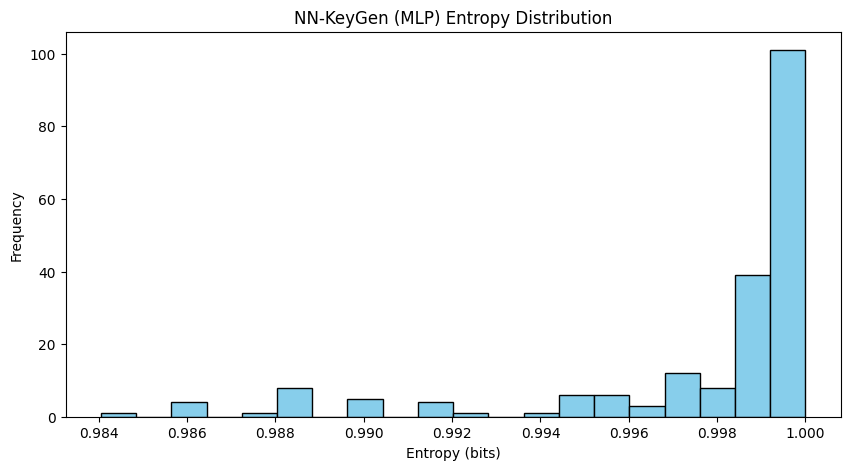

In [ ]:
# ====================================================
# 9️⃣ Histogram Görselleştirme
# ====================================================
plt.figure(figsize=(10,5))
plt.hist(entropies, bins=20, color='skyblue', edgecolor='black')
plt.title(f"NN-KeyGen ({MODEL_TYPE}) Entropy Distribution")
plt.xlabel("Entropy (bits)")
plt.ylabel("Frequency")
plt.show()